In [36]:
import rasterio as rio
from rasterio.mask import mask
from rasterio.plot import show
import geopandas as gpd
import numpy as np
import shapely
from src.mslandcover.config import MSTM_PROJ4

In [11]:
okt_raster_path = '/Volumes/dhester_ssd/NAIP_MS_2023/ortho_1-1_hc_s_ms105_2023_1/ortho_1-1_hc_s_ms105_2023_1_1m.tif'
census_ms_places_shp_path = '/Users/dak/Downloads/tl_2024_28_place/tl_2024_28_place.shp'
census_usa_counties_shp_path = '/Users/dak/Downloads/tl_2024_us_county/tl_2024_us_county.shp'

census_counties_gdf = gpd.read_file(census_usa_counties_shp_path)
ms_places_gdf = gpd.read_file(census_places_shp_path)

In [31]:
okt_county_geom = census_counties_gdf[(census_counties_gdf['STATEFP'] == '28') & (census_counties_gdf['COUNTYFP'] == '105')]['geometry'].values[0]
okt_county_places = ms_places_gdf[ms_places_gdf.intersects(okt_county_geom)]
starville_msu_gdf = okt_county_places[okt_county_places['NAME'].isin(['Starkville', 'Mississippi State'])]
starville_msu_gdf

,STATEFP,PLACEFP,PLACENS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,PCICBSA,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
181,28,70240,02405524,2870240,1600000US2870240,Starkville,Starkville city,25,C1,Y,G4110,A,71905428,387527,+33.4632610,-088.8277965,"POLYGON ((-88.87587 33.48181, -88.87588 33.483..."
372,28,48030,02586602,2848030,1600000US2848030,Mississippi State,Mississippi State CDP,57,U2,N,G4210,S,5657333,44921,+33.4510322,-088.7917862,"MULTIPOLYGON (((-88.78881 33.47428, -88.78858 ..."


/var/folders/1j/_j01624x6y33h54v02qwk81r0000gn/T/ipykernel_75874/358142688.py:3: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  starville_msu_geom = starville_msu_reproj_gdf.unary_union


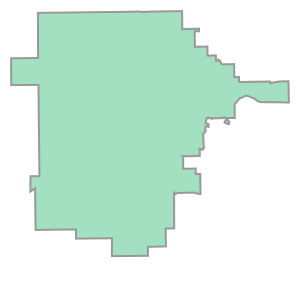

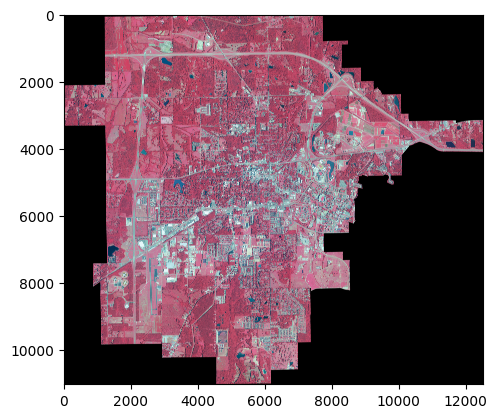

In [39]:
with rio.open(okt_raster_path) as src:
    starville_msu_reproj_gdf = starville_msu_gdf.to_crs(src.crs)
    starville_msu_geom = starville_msu_reproj_gdf.unary_union
    starville_msu_geom = shapely.Polygon(starville_msu_geom.exterior)
    display(starville_msu_geom)
    out_image, out_transform = mask(src, [starville_msu_geom], crop=True, all_touched=True)
    out_meta = src.meta.copy()

show(out_image)

out_meta.update({
    'driver': 'GTiff',
    'height': out_image.shape[1],
    'width': out_image.shape[2],
    'transform': out_transform,
    'crs': src.crs,
    'dtype': 'uint8',
    'count': 3,
    'compress': 'lzw',
    'nodata': 0,
})

with rio.open('/Volumes/dhester_ssd/mslc_inf_test/starkville_msu_2023.tif', 'w', **out_meta) as dst:
    dst.write(out_image)